# 🖼️ Unsupervised Image Segmentation with K-Means

In this notebook, we perform **image segmentation** using unsupervised **K-Means clustering** on pixel RGB values. The goal is to group similar pixels and reconstruct a simplified, segmented image.

We use a built-in example image from `skimage.data`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import data
from skimage.transform import rescale
from skimage.util import img_as_float

In [2]:
# Load a sample image and downscale it for speed
image = img_as_float(data.astronaut())  # RGB image
image = rescale(image, 0.25, anti_aliasing=True, channel_axis=-1)
h, w, c = image.shape
print(f'Image shape: {image.shape}')

Image shape: (128, 128, 3)


In [3]:
# Flatten the image to (n_pixels, 3)
X = image.reshape(-1, 3)

# Apply KMeans clustering to pixel colors
n_colors = 6
kmeans = KMeans(n_clusters=n_colors, random_state=42)
labels = kmeans.fit_predict(X)
segmented_img = kmeans.cluster_centers_[labels].reshape(h, w, 3)

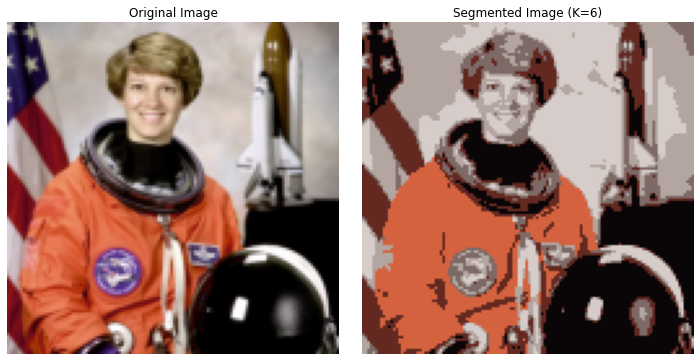

In [4]:
# Show original and segmented image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(segmented_img)
axes[1].set_title(f'Segmented Image (K={n_colors})')
axes[1].axis('off')
plt.tight_layout()
plt.show()